# Z4c TOV + Kerr-Schild XY-Plane Diagnostics

This notebook reads the `xy`-plane slice outputs from the low-compactness TOV-on-Kerr-Schild run in `analysis/z4c_tov_ks_xy_plane/`.

Current run settings:

- Uniform grid: `192 x 96 x 96`
- Domain: `x in [-12, 12]`, `y,z in [-6, 6]`
- Star center: `(x, y, z) = (8, 0, 0)`
- BH mass: `1`, spin: `0`
- Constraint damping: disabled (`damp_kappa1 = damp_kappa2 = 0`)

The Z4c slice output is the reconstructed full field, not the residual field.

In [1]:
from pathlib import Path
import sys
import pandas as pd

repo = Path.cwd()
while repo != repo.parent and not (repo / "vis" / "python").exists():
    repo = repo.parent
if str(repo) not in sys.path:
    sys.path.insert(0, str(repo))

from analysis.z4c_tov_ks_xy_plane.xy_plane_tools import (
    dump_numbers,
    plot_history,
    plot_plane_overview,
    plot_star_zoom,
    read_history,
    read_plane,
    select_run_dir,
)


Matplotlib is building the font cache; this may take a moment.


In [2]:
run_dir = select_run_dir("run_short")
mhd_hist = read_history(run_dir / "z4c_tov_ks_xy.mhd.hst")
z4c_hist = read_history(run_dir / "z4c_tov_ks_xy.z4c.user.hst")
available = dump_numbers(run_dir, "mhd")

print(f"Run directory: {run_dir}")
print(f"Available xy-plane dumps: {available}")
print(f"History samples: mhd={len(mhd_hist)}, z4c={len(z4c_hist)}")
mhd_hist


Run directory: /Users/hengrui/Desktop/research/gr/athenak/analysis/z4c_tov_ks_xy_plane/run_short
Available xy-plane dumps: [0]
History samples: mhd=2, z4c=2


,time,dt,mass,1-mom,2-mom,3-mom,tot-E,1-KE,2-KE,3-KE,1-ME,2-ME,3-ME
0,0.00,0.025,1.196330e-06,0.000000e+00,0.000000e+00,0.000000e+00,4.760520e-13,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.0,0.0
1,0.05,0.025,4.721140e-08,-5.804360e-19,9.179880e-37,-3.226730e-36,1.878640e-14,2.552280e-22,4.388250e-24,4.417560e-24,0.0,0.0,0.0


In [3]:
z4c_hist


,time,dt,C-norm2,H-norm2,M-norm2,Z-norm2,Mx-norm2,My-norm2,Mz-norm2,Theta-norm,Volume
0,0.00,0.025,253389.0,219285.0,34071.3,8.18419,200217.0,200217.0,200217.0,0.000000,3930.73
1,0.05,0.025,253389.0,219285.0,34071.3,8.18419,200217.0,200217.0,200217.0,0.000005,3930.73


Text(0.5, 0.98, 'Short Evolution History')

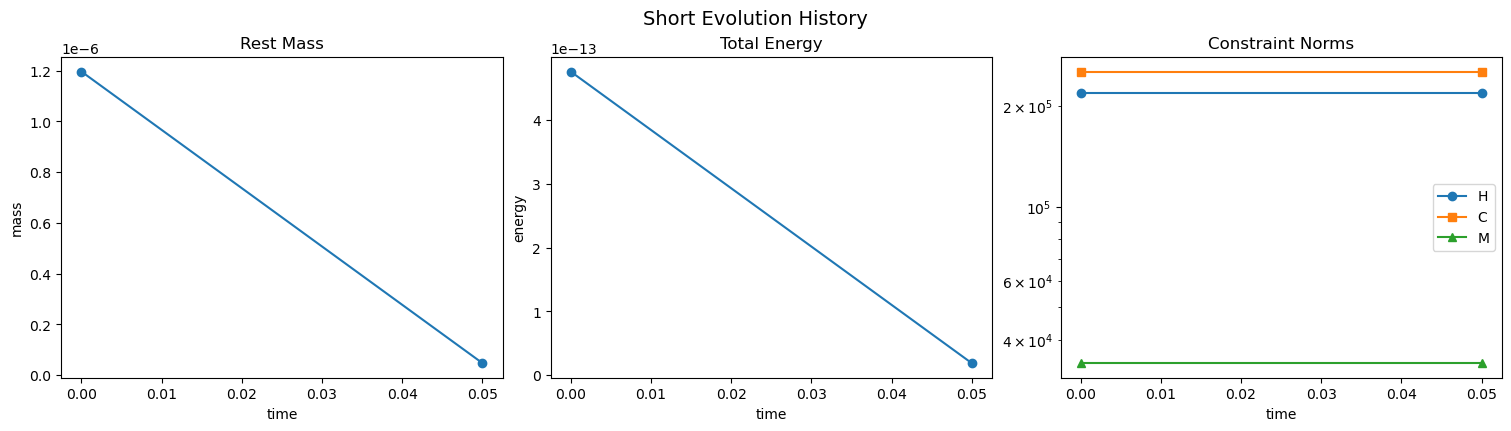

In [4]:
fig, _ = plot_history(mhd_hist, z4c_hist)
fig.suptitle("Short Evolution History", fontsize=14)


In [5]:
dump = available[-1]
mhd = read_plane(run_dir, "mhd", dump)
adm = read_plane(run_dir, "adm", dump)
z4c = read_plane(run_dir, "z4c", dump)

print(f"Using dump {dump:05d}")
print("MHD fields:", [key for key in mhd.keys() if key.startswith(("dens", "vel", "press", "temperature"))])
print("ADM fields:", [key for key in adm.keys() if key.startswith("adm_")][:6], "...")
print("Z4c fields:", [key for key in z4c.keys() if key.startswith("z4c_")][:8], "...")


Using dump 00000
MHD fields: ['dens', 'velx', 'vely', 'velz', 'press', 'temperature']
ADM fields: ['adm_gxx', 'adm_gxy', 'adm_gxz', 'adm_gyy', 'adm_gyz', 'adm_gzz'] ...
Z4c fields: ['z4c_chi', 'z4c_gxx', 'z4c_gxy', 'z4c_gxz', 'z4c_gyy', 'z4c_gyz', 'z4c_gzz', 'z4c_Khat'] ...


Text(0.5, 0.98, 'XY plane overview, dump 00000')

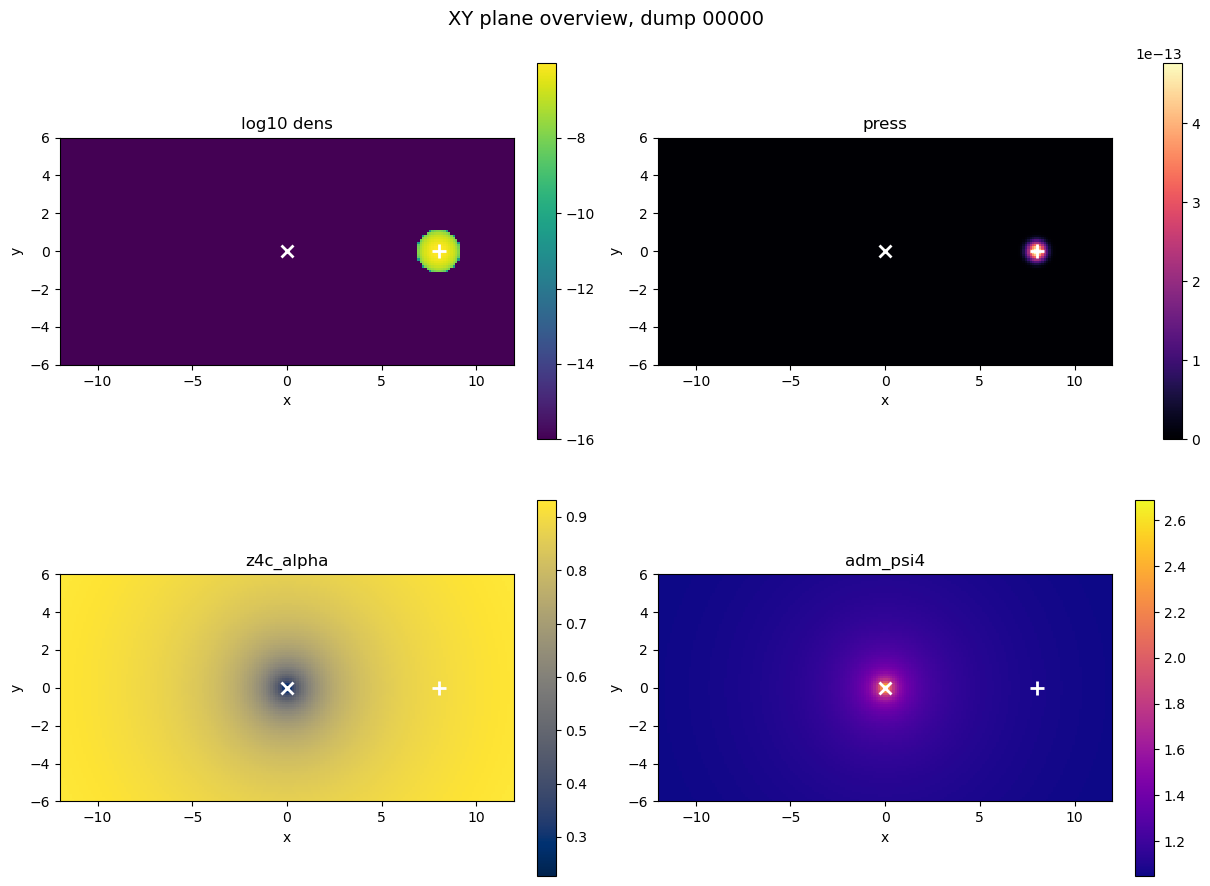

In [6]:
fig, _ = plot_plane_overview(mhd, adm, z4c)
fig.suptitle(f"XY plane overview, dump {dump:05d}", fontsize=14)


Text(0.5, 0.98, 'Star-centered zoom, dump 00000')

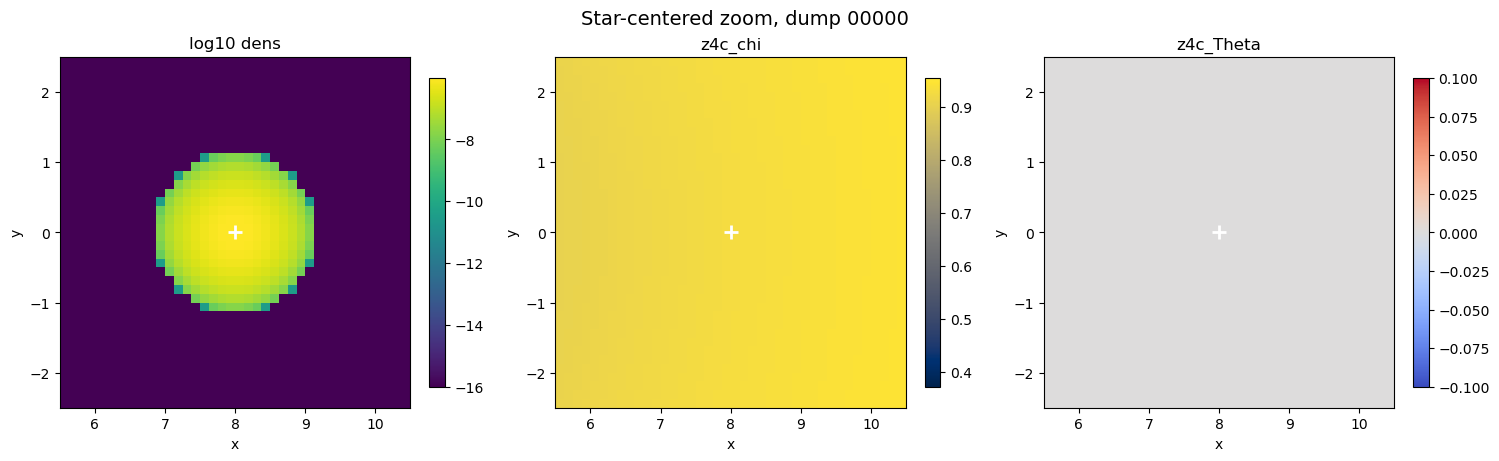

In [7]:
fig, _ = plot_star_zoom(mhd, z4c)
fig.suptitle(f"Star-centered zoom, dump {dump:05d}", fontsize=14)


If you generate additional slice dumps later, rerun the notebook and it will pick up the newest available dump automatically from the selected run directory.